In [59]:
import ast
import os
import pickle

import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [60]:
findings_path = os.path.join("vindr-mammo", "finding_annotations.csv")
metadata_path = os.path.join("vindr-mammo", "metadata.csv")

findings_df = pd.read_csv(findings_path)
metadata_df = pd.read_csv(metadata_path)

num_nan_birads = findings_df["breast_birads"].isna().sum()
num_nan_density = findings_df["breast_density"].isna().sum()
num_nan_findings = findings_df["finding_categories"].isna().sum()
num_duplicates = findings_df.duplicated().sum()
num_nan_age = metadata_df["Patient's Age"].isna().sum()

print(f"Number of NaN values in breast_birads: {num_nan_birads}")
print(f"Number of NaN values in breast_density: {num_nan_density}")
print(f"Number of NaN values in finding_categories: {num_nan_findings}")
print(f"Number of duplicate rows in findings_df: {num_duplicates}")
print(f"Number of NaN values in Patient's Age: {num_nan_age}")

Number of NaN values in breast_birads: 0
Number of NaN values in breast_density: 0
Number of NaN values in finding_categories: 0
Number of duplicate rows in findings_df: 0
Number of NaN values in Patient's Age: 2260


Number of NaN values in Patient's Age before imputation: 2648
Number of NaN values in Patient's Age after imputation: 0
Median age: 45.0


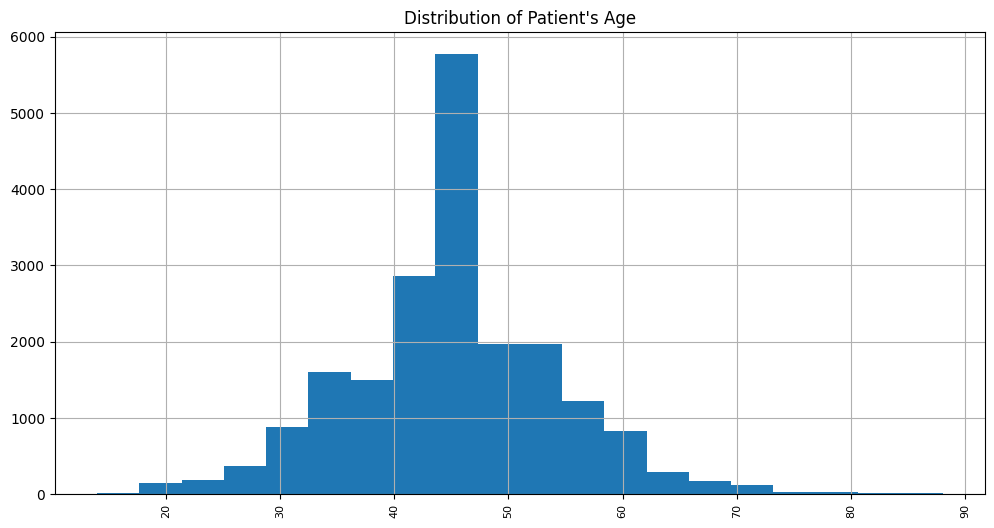

In [61]:
# Convert age to numeric, coercing errors to NaN
metadata_df["Patient's Age"] = metadata_df["Patient's Age"].apply(
    lambda x: int(x[:-1]) if isinstance(x, str) and int(x[:-1]) != 0 else np.nan
)

# Convert BI-RADS to numeric, coercing errors to NaN
findings_df["breast_birads"] = findings_df["breast_birads"].apply(
    lambda x: int(x[-1:]) if isinstance(x, str) else np.nan
)

# Convert breast density to categorical values
findings_df["breast_density"] = findings_df["breast_density"].apply(
    lambda x: x[-1:] if isinstance(x, str) else np.nan
)
# Convert breast density to numeric values
density_mapping = {"A": 1, "B": 2, "C": 3, "D": 4}
findings_df["breast_density"] = findings_df["breast_density"].map(density_mapping)

# Engineer diagnosis feature
findings_df["diagnosis"] = (findings_df["breast_birads"] >= 4).astype(int)

num_nan_age = metadata_df["Patient's Age"].isna().sum()
print(f"Number of NaN values in Patient's Age before imputation: {num_nan_age}")

# Impute missing values in patient's age using the median age
imputer = SimpleImputer(strategy="median")
metadata_df["Patient's Age"] = imputer.fit_transform(metadata_df[["Patient's Age"]])
num_nan_age = metadata_df["Patient's Age"].isna().sum()
print(f"Number of NaN values in Patient's Age after imputation: {num_nan_age}")
print(f"Median age: {metadata_df['Patient\'s Age'].median()}")

fig, ax = pyplot.subplots(1, 1, figsize=(12, 6))
metadata_df["Patient's Age"].hist(bins=20, xrot=90, xlabelsize=8, ax=ax)
ax.set_title("Distribution of Patient's Age")
pyplot.show()

In [62]:
needed_findings_columns = [
    "study_id",
    "image_id",
    "laterality",
    "view_position",
    "breast_birads",
    "breast_density",
    "finding_categories",
    "diagnosis",
]
needed_metadata_columns = ["SOP Instance UID", "Patient's Age"]
findings_df = findings_df[needed_findings_columns]
metadata_df = metadata_df[needed_metadata_columns]

# Merge the findings and metadata DataFrames on the SOP Instance UID (image ID) column
merged_df = pd.merge(
    findings_df,
    metadata_df,
    left_on="image_id",
    right_on="SOP Instance UID",
    how="inner",
)

# Drop the SOP Instance UID column
merged_df.drop(columns=["SOP Instance UID"], inplace=True)

# Drop duplicate rows based on image_id, keeping the first occurrence
merged_df.drop_duplicates(subset=["image_id"], keep="first", inplace=True)
merged_df.reset_index(drop=True, inplace=True)

# Compute image path
merged_df["image_path"] = merged_df.apply(
    lambda row: os.path.join(
        "vindr-mammo", "images", row["study_id"], row["image_id"] + ".png"
    ),
    axis=1,
)

print(f"Number of unique study IDs: {merged_df['study_id'].nunique()}")
print(f"Number of unique image IDs: {merged_df['image_id'].nunique()}")

merged_df

Number of unique study IDs: 5000
Number of unique image IDs: 20000


,study_id,image_id,laterality,view_position,breast_birads,breast_density,finding_categories,diagnosis,Patient's Age,image_path
0,48575a27b7c992427041a82fa750d3fa,4e3a578fe535ea4f5258d3f7f4419db8,R,CC,4,3,['Mass'],1,41.0,vindr-mammo/images/48575a27b7c992427041a82fa75...
1,48575a27b7c992427041a82fa750d3fa,dac39351b0f3a8c670b7f8dc88029364,R,MLO,4,3,['Mass'],1,41.0,vindr-mammo/images/48575a27b7c992427041a82fa75...
2,75e8e48933289d70b407379a564f8594,c83f780904f25eacb44e9030f32c66e1,R,CC,3,3,['Global Asymmetry'],0,48.0,vindr-mammo/images/75e8e48933289d70b407379a564...
3,75e8e48933289d70b407379a564f8594,893528bc38a0362928a89364f1b692fd,R,MLO,3,3,['Global Asymmetry'],0,48.0,vindr-mammo/images/75e8e48933289d70b407379a564...
4,c3487424fee1bdd4515b72dc3fd69813,318264c881bf12f2c1efe5f93920cc37,R,CC,4,3,['Architectural Distortion'],1,48.0,vindr-mammo/images/c3487424fee1bdd4515b72dc3fd...
...,...,...,...,...,...,...,...,...,...,...
19995,f2093a752e6b44df5990f5fd38c99dd2,ea732154d149f619b20070b78060ae65,R,CC,2,3,['No Finding'],0,38.0,vindr-mammo/images/f2093a752e6b44df5990f5fd38c...
19996,b3c8969cd2accfa4dbb2aece1f7158ab,4689616c3d0b46fcba7a771107730791,R,CC,2,3,['No Finding'],0,18.0,vindr-mammo/images/b3c8969cd2accfa4dbb2aece1f7...
19997,b3c8969cd2accfa4dbb2aece1f7158ab,3c22491bcf1d0b004715c28d80981cdd,L,CC,2,3,['No Finding'],0,18.0,vindr-mammo/images/b3c8969cd2accfa4dbb2aece1f7...
19998,b3c8969cd2accfa4dbb2aece1f7158ab,d443b9725e331b8b27589aa725597801,R,MLO,2,3,['No Finding'],0,18.0,vindr-mammo/images/b3c8969cd2accfa4dbb2aece1f7...


In [63]:
# Convert the categorical variables to one hot encoded vectors

# Convert finding-categories
finding_categories = []

for categories in merged_df["finding_categories"].to_numpy():
    # Convert the string-list to an actual list
    categories_list = ast.literal_eval(categories)

    for category in categories_list:
        if category not in finding_categories:
            finding_categories.append(category)

del finding_categories[-1]  # Delete `No Finding` category

print(finding_categories)


def get_findings_vector(x):
    vector = [0] * len(finding_categories)

    for category in ast.literal_eval(x):
        if category in finding_categories:
            index = finding_categories.index(category)
            vector[index] = 1

    return vector


merged_df["finding_categories"] = merged_df["finding_categories"].apply(
    get_findings_vector
)

# Convert breast birads and breast density
birads_encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")
density_encoder = OneHotEncoder(sparse_output=False, handle_unknown="error")

merged_df["breast_birads"] = list(
    birads_encoder.fit_transform(merged_df[["breast_birads"]]).astype(int)
)
merged_df["breast_density"] = list(
    density_encoder.fit_transform(merged_df[["breast_density"]]).astype(int)
)

# Save the encoders
birads_encoder_path = os.path.join("models", "birads_encoder.pkl")
density_encoder_path = os.path.join("models", "density_encoder.pkl")

with open(birads_encoder_path, "wb") as f:
    pickle.dump(birads_encoder, f)

with open(density_encoder_path, "wb") as f:
    pickle.dump(density_encoder, f)

merged_df

['Mass', 'Global Asymmetry', 'Architectural Distortion', 'Nipple Retraction', 'Suspicious Calcification', 'Focal Asymmetry', 'Asymmetry', 'Skin Thickening', 'Suspicious Lymph Node', 'Skin Retraction']


,study_id,image_id,laterality,view_position,breast_birads,breast_density,finding_categories,diagnosis,Patient's Age,image_path
0,48575a27b7c992427041a82fa750d3fa,4e3a578fe535ea4f5258d3f7f4419db8,R,CC,"[0, 0, 0, 1, 0]","[0, 0, 1, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,41.0,vindr-mammo/images/48575a27b7c992427041a82fa75...
1,48575a27b7c992427041a82fa750d3fa,dac39351b0f3a8c670b7f8dc88029364,R,MLO,"[0, 0, 0, 1, 0]","[0, 0, 1, 0]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",1,41.0,vindr-mammo/images/48575a27b7c992427041a82fa75...
2,75e8e48933289d70b407379a564f8594,c83f780904f25eacb44e9030f32c66e1,R,CC,"[0, 0, 1, 0, 0]","[0, 0, 1, 0]","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]",0,48.0,vindr-mammo/images/75e8e48933289d70b407379a564...
3,75e8e48933289d70b407379a564f8594,893528bc38a0362928a89364f1b692fd,R,MLO,"[0, 0, 1, 0, 0]","[0, 0, 1, 0]","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]",0,48.0,vindr-mammo/images/75e8e48933289d70b407379a564...
4,c3487424fee1bdd4515b72dc3fd69813,318264c881bf12f2c1efe5f93920cc37,R,CC,"[0, 0, 0, 1, 0]","[0, 0, 1, 0]","[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]",1,48.0,vindr-mammo/images/c3487424fee1bdd4515b72dc3fd...
...,...,...,...,...,...,...,...,...,...,...
19995,f2093a752e6b44df5990f5fd38c99dd2,ea732154d149f619b20070b78060ae65,R,CC,"[0, 1, 0, 0, 0]","[0, 0, 1, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0,38.0,vindr-mammo/images/f2093a752e6b44df5990f5fd38c...
19996,b3c8969cd2accfa4dbb2aece1f7158ab,4689616c3d0b46fcba7a771107730791,R,CC,"[0, 1, 0, 0, 0]","[0, 0, 1, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0,18.0,vindr-mammo/images/b3c8969cd2accfa4dbb2aece1f7...
19997,b3c8969cd2accfa4dbb2aece1f7158ab,3c22491bcf1d0b004715c28d80981cdd,L,CC,"[0, 1, 0, 0, 0]","[0, 0, 1, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0,18.0,vindr-mammo/images/b3c8969cd2accfa4dbb2aece1f7...
19998,b3c8969cd2accfa4dbb2aece1f7158ab,d443b9725e331b8b27589aa725597801,R,MLO,"[0, 1, 0, 0, 0]","[0, 0, 1, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0,18.0,vindr-mammo/images/b3c8969cd2accfa4dbb2aece1f7...


In [64]:
# Save the processed metadata file
breast_metadata_path = os.path.join("vindr-mammo", "breast_metadata.csv")
merged_df.to_csv(breast_metadata_path, index=False)